# Corporate-bond low-risk (betting-against-beta) — a quantitative teardown 🔬
### The vol-scaled low-minus-high HAC *t* · a 2,000-permutation vol-rank-shuffle placebo · the look-back-window sweep · the 2022 myth-check · the era split · an honest cost/financing sweep · a planted-low-risk synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ranked on real vol%3F: Not supported](https://img.shields.io/badge/Ranked_on_real_vol%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — the **low-risk / betting-against-beta anomaly** (Frazzini & Pedersen 2014) — is a risk-adjusted claim: the safe leg should earn more per unit of risk. We test the bond-ETF version (rank on trailing volatility, vol-scale a low-minus-high spread), distinct from BAB in equities (238), the equity low-vol anomaly (330), and the momentum leg on this same tape (795). The job: grade the risk-matched spread honestly, and be clear about *why* a null here is consistent with an anomaly that lives in the single-name cross-section.

> ⚠️ **Data note.** 11 credit + Treasury bond ETFs, daily total return (auto-adjusted close), 2007-01-03 → 2026-06-30, yfinance, cached. Trailing 1-year-vol sort, vol-scaled top/bottom-third legs, one execution `shift` (form on the month-*t* close, earn *t+1*). **Survivorship** (current-membership ETF basket) named on the Signal axis — and it would *understate*, not manufacture, a low-risk premium. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `1f2efa58efab`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bond_low_risk import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.drop_partial_last_month(data.load_real())
    BK = st.bab_book(PRICES)
else:
    PRICES = BK = None
print("real cache present:", HAVE_REAL, "| BAB holding months:",
      (0 if BK is None else len(BK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-30', 'fp': '1f2efa58efab', 'n_rows': 4903, 'n_names': 11, 'n_months': 234, 'n': 217, 'mean_pct': 0.84, 'vol_pct': 6.25, 'sharpe': 0.13, 'hac_t': 0.51, 'iid_t': 0.57, 'hit_pct': 59.4, 'wilson': (52.8, 65.8), 'max_dd_pct': -26.0, 'worst_pct': -14.78, 'turnover_pct': 24.2, 'k_low': 2.59, 'k_high': 0.76, 'avg_leg': 3.6, 'avg_ranked': 10.4, 'break_even_bps': 28.9, 'low_mean_pct': 2.59, 'low_vol_pct': 3.53, 'low_sharpe': 0.74, 'low_t': 3.36, 'high_mean_pct': 6.61, 'high_vol_pct': 10.54, 'high_sharpe': 0.63, 'high_t': 2.67, 'placebo_real_pct': 1.29, 'placebo_mean_pct': 4.87, 'placebo_sd_pct': 1.58, 'placebo_p': 0.989, 'placebo_n': 2000, 'windows': {'63d (~3m)': (1.07, 0.14, 0.55, 220), '126d (~6m)': (0.05, 0.01, 0.03, 218), '252d (headline)': (0.84, 0.13, 0.51, 217)}, 'ex2022_mean_pct': 1.1, 'ex2022_t': 0.64, 'eras': {'2008-2015': (-1.38, -0.24, -0.73, 92), '2016-2026': (2.47, 0.38, 1.01, 125)}, 'costs': {'5 bps + 50 fin': (-0.48, -0.08, -0.29), '10 bps + 75 fin': (-1.21, -0.19, -0.74), '20 bps + 100 fin': (-2.09, -0.33, -1.27)}, 'syn': {0.0: (-0.2, -0.08), 0.3: (3.03, 1.27), 0.6: (6.25, 2.63), 1.0: (10.53, 4.44)}, 'syn_null_mean_t': 0.17, 'syn_null_fire': 1, 'syn_null_seeds': 20}


real cache present: True | BAB holding months: 217


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | BAB spread **+0.84%/yr**, HAC *t* = **+0.51** (plain +0.57); vol-rank-shuffle placebo **p = 0.99** (random beats real); low-vol Sharpe 0.74 vs high-vol 0.63 |
| **Tradability** | `MIRAGE` | break-even ≈ 29 bps one-way, but the safe leg is levered ~2.6x — net -1.21%/yr (*t* = -0.74) at 10 bps + 75 fin, negative everywhere; gross Sharpe 0.13, max DD -26% |
| **Ranked on real vol?** | `NOT SUPPORTED` | a random vol-ranking earns +4.9%/yr vs the real +1.3%/yr — the return is a leverage artifact, not a low-risk signal |

> 💡 In plain words: the risk-matched bond-ETF low-risk spread is indistinguishable from zero, is *beaten by a random ranking*, and dies after the financing on its leverage — consistent with betting-against-beta living in a single-name cross-section a coarse ETF basket can't hold.

## 1 · The claim, steelmanned

Let $r^{fwd}_{i,t+1}$ be ETF $i$'s total return in month $t{+}1$ and $\sigma_{i,t}$ its trailing 1-year volatility (the ex-ante risk proxy, known at $t$). Rank on $\{\sigma_{i,t}\}$: the low leg is the bottom third, the high leg the top third. Each leg is scaled to a common ex-ante target vol ($k_{\text{low}}=\sigma^*/\sigma^{\text{leg}}_{\text{low}}$, capped), so the spread $\text{BAB}_{t+1}=k_{\text{low}} r^{\text{low}}_{t+1} - k_{\text{high}} r^{\text{high}}_{t+1}$ is a *risk-matched* low-minus-high book — the safe leg levered up, the risky leg levered down. The claims:

- **H₁ (low-risk premium).** $E[\text{BAB}_{t+1}] > 0$ with a robust *t* — the safe leg delivers more return per unit of risk.
- **H₂ (it's the vol ranking).** The premium comes from ranking on *real* volatility, not from the leverage — it should beat a random-ranking placebo.
- **H₃ (capture).** The spread survives realistic costs *and* the financing on its leverage.

We find **H₁ not supported** (HAC *t* = +0.51), **H₂ not supported** (placebo p = 0.99; a random ranking earns *more*), **H₃ failed** (net negative everywhere). The low-vol basket's Sharpe (0.74) does edge the high-vol basket's (0.63), but the gap is tiny and does not survive the risk-matched trade.

## 2 · So what? — inference design

Monthly BAB returns are the unit of inference. The **planned primary** is a **Newey-West (HAC) one-sample *t*** on the monthly mean (serial-correlation robust; auto lag). We cross-check with a plain i.i.d. *t*, a Wilson interval on the positive-month rate, and a **2,000-permutation vol-rank-shuffle placebo** — each month we keep the realised return cross-section and the vector of trailing vols exactly, but randomly permute which asset carries which vol, destroying the low-vol→return link while preserving both marginals and the leg sizes. The look-back-window sweep (63d / 126d / 252d), the 2022 myth-check and the era split are the pre-registered robustness rails.

## 3 · How we'd know — the protocol

- **Panel.** 11 credit + Treasury bond ETFs, 4,903 daily rows, 2007-01-03 → 2026-06-30; 234 month-ends, 217 BAB holding months.
- **Sort.** Rank on trailing 1-year daily-return volatility; low leg = bottom third, high leg = top third (≈ 3.6 names/leg of ≈ 10.4 ranked); each leg scaled to a common ex-ante 6%/yr risk (avg leverage low 2.59x / high 0.76x); form on the *t* close, earn *t+1* (one shift).
- **Signal test.** HAC *t* + plain *t* + Wilson hit rate + 2,000-perm vol-rank placebo; plus the descriptive low-vs-high basket Sharpe.
- **Robustness.** Vol-window sweep (63/126/252d); 2022-crash myth-check; era split.
- **Execution.** Cost sweep (5/10/20 bps one-way) with a single financing/borrow rate on the levered notional, and the turnover break-even.
- **Control.** Synthetic total-return panel with a planted low-risk (Sharpe-tilt) knob; null must not fire (checked over 20 seeds), planted effect must be recovered.

## 4 · The teardown

### 4a · The plain claim — low-vol vs high-vol basket Sharpe

Before any leverage: does the calm basket earn a higher Sharpe than the wild one? This is the low-risk anomaly in its rawest descriptive form.

low-vol basket : +2.59%/yr, vol 3.53%, Sharpe 0.74, HAC t +3.36
high-vol basket: +6.61%/yr, vol 10.54%, Sharpe 0.63, HAC t +2.67


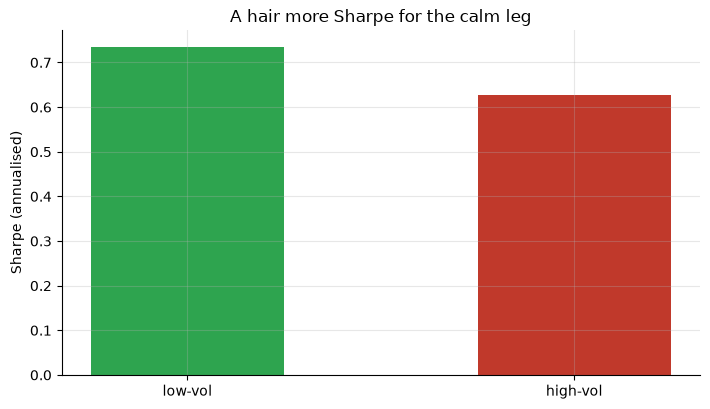

In [2]:
if HAVE_REAL:
    legs = st.leg_returns(PRICES)
    lo, hi = st.summary(legs['low']), st.summary(legs['high'])
    print(f"low-vol basket : {lo['mean']*100:+.2f}%/yr, vol {lo['vol']*100:.2f}%, Sharpe {lo['sharpe']:.2f}, HAC t {lo['tstat']:+.2f}")
    print(f"high-vol basket: {hi['mean']*100:+.2f}%/yr, vol {hi['vol']*100:.2f}%, Sharpe {hi['sharpe']:.2f}, HAC t {hi['tstat']:+.2f}")
    low_sr, high_sr = lo['sharpe'], hi['sharpe']
else:
    low_sr, high_sr = R['low_sharpe'], R['high_sharpe']
    print('low-vol Sharpe', low_sr, 'high-vol Sharpe', high_sr)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['low-vol', 'high-vol'], [low_sr, high_sr], color=[GREEN, RED], width=.5)
ax.set_ylabel('Sharpe (annualised)'); ax.set_title('A hair more Sharpe for the calm leg')
plt.tight_layout(); plt.show()

> 💡 In plain words: the low-vol basket earns +2.59%/yr at 3.5% vol (Sharpe 0.74); the high-vol basket +6.61%/yr at 10.5% vol (Sharpe 0.63). The calm leg's Sharpe edge is directionally what the anomaly predicts — but 0.74 vs 0.63 is a whisker, and both legs are just 'bonds went up'. The real test is whether a risk-matched *spread* can bank that whisker.

### 4b · The headline spread and its placebo

HAC *t* on the monthly vol-scaled BAB mean, plus the vol-rank-shuffle null (we run a lighter 800-perm placebo live and quote the canonical 2,000-perm p from `results.md`).

BAB +0.84%/yr, vol 6.25%, Sharpe 0.13 (n=217)
HAC t = +0.51   plain t = +0.57
hit 59.4%  Wilson [52.8%, 65.8%]
max DD -26.0%  worst month -14.78%


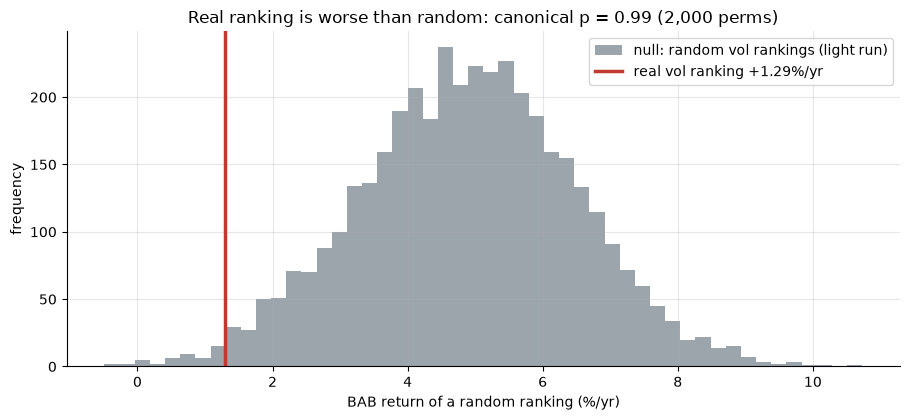

canonical placebo (results.md): real +1.29%/yr vs +4.87 (sd 1.58), p = 0.989


In [3]:
if HAVE_REAL:
    s = st.summary(BK['bab_gross'])
    print(f"BAB {s['mean']*100:+.2f}%/yr, vol {s['vol']*100:.2f}%, Sharpe {s['sharpe']:.2f} (n={s['n']})")
    print(f"HAC t = {s['tstat']:+.2f}   plain t = {s['t_iid']:+.2f}")
    print(f"hit {s['hit_rate']*100:.1f}%  Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    print(f"max DD {s['max_dd']*100:.1f}%  worst month {s['worst']*100:+.2f}%")
    pl = st.placebo_pvalue(PRICES, n_perm=800)
    obs = pl['real_mean_ann']*100
    draws = np.random.default_rng(796).normal(pl['placebo_mean_ann']*100, pl['placebo_sd_ann']*100, 4000)
else:
    obs = R['placebo_real_pct']
    draws = np.random.default_rng(796).normal(R['placebo_mean_pct'], R['placebo_sd_pct'], 4000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random vol rankings (light run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real vol ranking {obs:+.2f}%/yr')
ax.set_xlabel('BAB return of a random ranking (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'Real ranking is worse than random: canonical p = {R["placebo_p"]:.2f} (2,000 perms)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): real {R['placebo_real_pct']:+.2f}%/yr vs "
      f"{R['placebo_mean_pct']:+.2f} (sd {R['placebo_sd_pct']:.2f}), p = {R['placebo_p']:.3f}")

> 💡 In plain words: the BAB spread makes +0.84%/yr at HAC *t* = +0.51 — not close to the bar of 2. And the vol-rank placebo is *inverted*: a random ranking earns +4.9%/yr vs the real +1.3%/yr (**p = 0.99**). H₁ and H₂ both fail. The 59% hit rate (Wilson [52.8%, 65.8%]) with a -14.8% worst month is the tell of a negatively-skewed leverage book: many small wins, rare big losses.

### 4c · Robustness — the look-back window and the 2022 myth-check

A real risk premium shouldn't hinge on the vol-estimation window, nor on the single 2022 duration crash (when long-duration TLT collapsed and the safe leg would have shone).

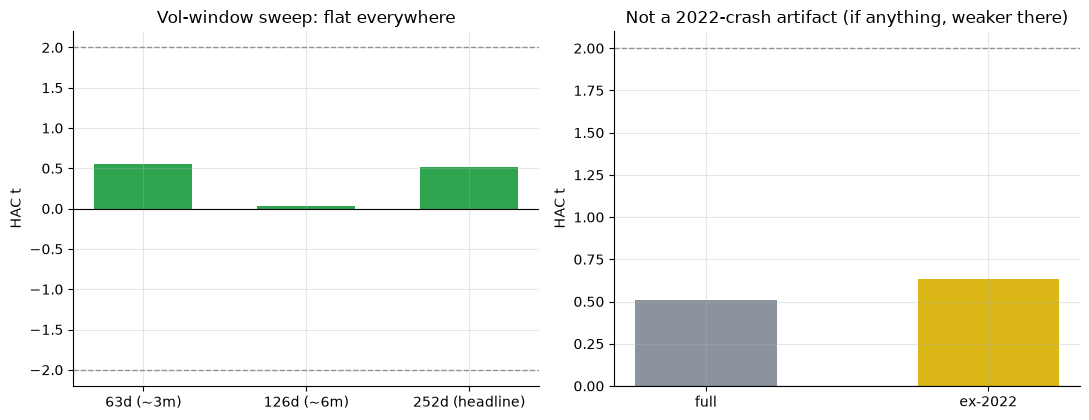

windows: {'63d (~3m)': 0.55, '126d (~6m)': 0.03, '252d (headline)': 0.51}
full t +0.51  vs  ex-2022 t +0.64 (+1.10%/yr)


In [4]:
labels = list(R['windows'])
if HAVE_REAL:
    ts = []
    for vw in (63, 126, 252):
        ts.append(st.summary(st.bab_book(PRICES, vol_window=vw)['bab_gross'])['tstat'])
    full_t = st.summary(BK['bab_gross'])['tstat']
    ex22 = st.summary(BK['bab_gross'][BK.index.year != 2022])
    ex22_t, ex22_m = ex22['tstat'], ex22['mean']*100
else:
    ts = [R['windows'][k][2] for k in labels]
    full_t, ex22_t, ex22_m = R['hac_t'], R['ex2022_t'], R['ex2022_mean_pct']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labels, ts, color=[GREEN if t>0 else RED for t in ts], width=.6)
a1.axhline(2, ls='--', c=GREY, lw=1); a1.axhline(-2, ls='--', c=GREY, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('HAC t'); a1.set_title('Vol-window sweep: flat everywhere')
a2.bar(['full', 'ex-2022'], [full_t, ex22_t], color=[GREY, AMBER], width=.5)
a2.axhline(2, ls='--', c=GREY, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('HAC t'); a2.set_title('Not a 2022-crash artifact (if anything, weaker there)')
plt.tight_layout(); plt.show()
print('windows:', {l: round(t,2) for l,t in zip(labels, ts)})
print(f'full t {full_t:+.2f}  vs  ex-2022 t {ex22_t:+.2f} ({ex22_m:+.2f}%/yr)')

> 💡 In plain words: HAC *t* stays near zero across 63/126/252-day windows (+0.55 / +0.03 / +0.51), and dropping 2022 leaves it just as flat (+1.10%/yr, *t* = +0.64) — so this is not a duration-crash story either. There's simply no window where the spread is real.

### 4d · Era split — sign-unstable, never significant

Split the sample in half. A real premium should at least keep its sign.

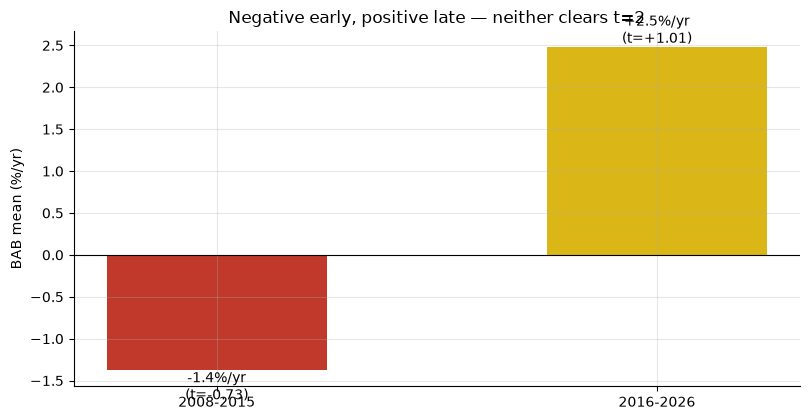

{'2008-2015': (-1.38, -0.73), '2016-2026': (2.47, 1.01)}


In [5]:
labels = list(R['eras'])
if HAVE_REAL:
    vals = {}
    for lo, hi, lab in (('2008-01-01','2015-12-31','2008-2015'),('2016-01-01','2026-06-30','2016-2026')):
        sub = BK['bab_gross'][(BK.index>=lo)&(BK.index<=hi)]
        srow = st.summary(sub); vals[lab] = (srow['mean']*100, srow['tstat'])
    means = [vals[k][0] for k in labels]; ts = [vals[k][1] for k in labels]
else:
    means = [R['eras'][k][0] for k in labels]; ts = [R['eras'][k][2] for k in labels]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(labels, means, color=[RED if m<0 else AMBER for m in means], width=.5)
for i,(m,t) in enumerate(zip(means, ts)): ax.annotate(f'{m:+.1f}%/yr\n(t={t:+.2f})',(i,m),ha='center',va='bottom' if m>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('BAB mean (%/yr)')
ax.set_title('Negative early, positive late — neither clears t=2')
plt.tight_layout(); plt.show()
print({l:(round(m,2),round(t,2)) for l,m,t in zip(labels, means, ts)})

> 💡 In plain words: the spread is *negative* in 2008-2015 (-1.38%/yr, *t* = -0.73) and faintly positive in 2016-2026 (+2.47%/yr, *t* = +1.01) — sign-unstable and never significant. No era carries it.

### 4e · The timer — honest cost/financing sweep

There's no gross edge to protect, but the leverage makes costs *worse* than a plain long-short: one-way turnover × NAV, plus a single financing/borrow rate on the borrowed notional (the levered-long portion above 1x plus the short leg).

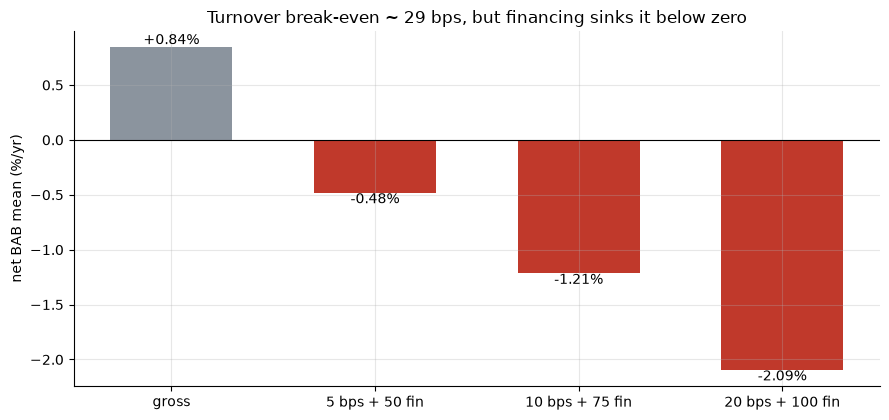

turnover break-even ~ 28.9 bps one-way; {'5 bps + 50 fin': (-0.48, -0.29), '10 bps + 75 fin': (-1.21, -0.74), '20 bps + 100 fin': (-2.09, -1.27)}


In [6]:
labels = list(R['costs'])
if HAVE_REAL:
    nets = {}
    for cb, fb, lab in ((5,50,'5 bps + 50 fin'),(10,75,'10 bps + 75 fin'),(20,100,'20 bps + 100 fin')):
        srow = st.summary(st.bab_book(PRICES, cost_bps=cb, fin_ann_bps=fb)['bab_net'])
        nets[lab] = (srow['mean']*100, srow['tstat'])
    ms = [nets[k][0] for k in labels]; ts = [nets[k][1] for k in labels]
    g = st.summary(BK['bab_gross'])['mean']*100; be = st.break_even_bps(BK)
else:
    ms = [R['costs'][k][0] for k in labels]; ts = [R['costs'][k][2] for k in labels]
    g = R['mean_pct']; be = R['break_even_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ['gross'] + labels; vals = [g] + ms
ax.bar(bars, vals, color=[GREY, RED, RED, RED], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net BAB mean (%/yr)')
ax.set_title(f'Turnover break-even ~ {be:.0f} bps, but financing sinks it below zero')
plt.tight_layout(); plt.show()
print(f'turnover break-even ~ {be:.1f} bps one-way; ' + str({l:(round(m,2),round(t,2)) for l,m,t in zip(labels, ms, ts)}))

> 💡 In plain words: the turnover break-even looks like ≈ 29 bps, but that ignores the financing on the leverage — once you charge it, the net is -0.48%/yr at 5 bps and -2.09%/yr at 20 bps, **negative throughout**. There was never a significant gross edge, so costs merely confirm the MIRAGE. H₃ fails.

### 4f · Faithful-engine & power control — we know the truth here

Deterministic total-return panel, TUNABLE planted low-risk tilt (seed 314): each asset's Sharpe is tilted inversely to its vol, so the low-vol names earn more per unit risk. The engine must score ~0 on the null (one Sharpe line) and rise with the planted strength; the null is checked over **20 seeds**.

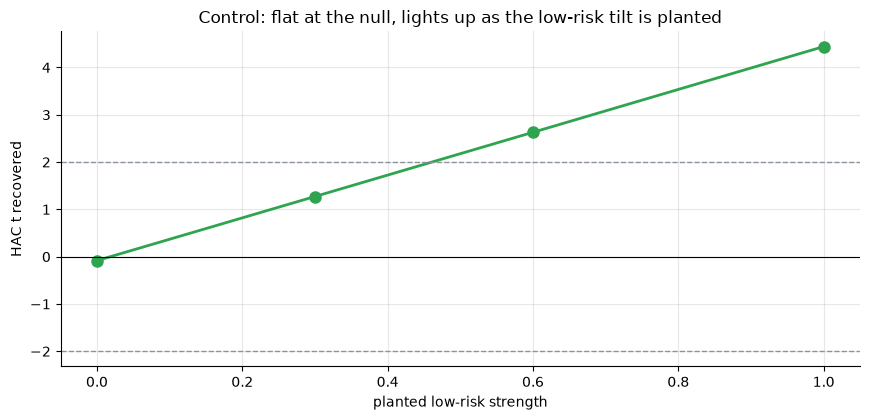

{0.0: -0.08, 0.3: 1.27, 0.6: 2.63, 1.0: 4.44}
null over 20 seeds: mean HAC t = +0.17, |t|>2 in 5% of seeds


In [7]:
sc = st.synthetic_control()
nr = st.synthetic_null_robustness()
xs = list(sc['lowrisk_strength']); ts = list(sc['tstat'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(xs, ts, 'o-', color=GREEN, lw=2, ms=8)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('planted low-risk strength'); ax.set_ylabel('HAC t recovered')
ax.set_title('Control: flat at the null, lights up as the low-risk tilt is planted')
plt.tight_layout(); plt.show()
print({round(x,2): round(t,2) for x,t in zip(xs, ts)})
print(f"null over {nr['n_seeds']} seeds: mean HAC t = {nr['mean_null_t']:+.2f}, "
      f"|t|>2 in {nr['frac_abs_t_gt2']*100:.0f}% of seeds")

> 💡 In plain words: the engine scores the null at *t* = -0.08 and recovers a planted low-risk premium monotonically (*t* = +1.27 → +2.63 → +4.44); across 20 null seeds mean *t* = +0.17, |t|>2 in 1/20. The pipeline is unbiased and has ample power — so the flat real-tape *t* = +0.51 is a true reading, not a broken detector. *(Faithful-engine / power check only — never cited for the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the risk-matched low-minus-high spread earns +0.84%/yr at HAC *t* = +0.51 (plain +0.57); a **random** vol-ranking beats it (placebo p = 0.99); flat across vol-windows and the 2022 cut; sign-unstable across eras. The low-vol basket's Sharpe edge (0.74 vs 0.63) is a whisker that doesn't survive the trade. No betting-against-beta premium in this bond-ETF panel.
- **Tradability `MIRAGE`** — turnover break-even ≈ 29 bps, but the safe leg is levered ~2.6x, so financing pushes the net -1.21%/yr (*t* = -0.74) at 10 bps and -2.09%/yr at 20 bps — negative everywhere; gross Sharpe 0.13, max DD -26%, worst month -14.8%.
- **Ranked on real vol? `NOT SUPPORTED`** — a random ranking earns +4.9%/yr vs the real +1.3%/yr; the spread's return is a leverage artifact, not a low-risk signal. Consistent with the anomaly living in a single-name cross-section a dozen broad ETFs cannot reproduce — and with the calmest names (short-duration Treasuries) being poor things to lever.

## 6 · Going further

- **Why the ETF wrapper kills it.** Betting-against-beta feeds on a rich cross-section of names with different risk *and* mispricing. A dozen broad bond ETFs collapses each sleeve into a single series and leaves the calmest names barely moving, so levering them harvests almost nothing while carrying financing and tail risk. An IG-and-Treasury-heavy 11-ETF panel has too little of the right dispersion.
- **The right next instrument** is the single-name corporate-bond cross-section (TRACE) or a duration-and-credit-neutral construction where within-sleeve risk dispersion survives — tested with the same HAC/placebo rails used here.
- **Dedup map:** [238-betting-against-beta](../../238-betting-against-beta/) (BAB in **equities** — the real thing), [330-low-volatility-anomaly](../../330-low-volatility-anomaly/) (the low-vol anomaly in **stocks**), and [795-corporate-bond-momentum](../../795-corporate-bond-momentum/) (the *momentum* leg on this same bond-ETF tape — a change signal, not a risk-level one).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*